# Milestone 3 — Clustering Algorithm Comparison

Fits K-Means, Agglomerative, DBSCAN, GMM on the M2 feature matrix (33 features), evaluates,
runs bootstrap stability, and selects the final model. Clusters on the FULL feature matrix
(not PCA-reduced) because PCA collapsed to 1 component on this dataset.


In [1]:
import sys; sys.path.append('..')
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

from src.clustering import fit_kmeans, fit_agglomerative, fit_dbscan, fit_gmm, select_k_kmeans
from src.evaluation import evaluation_metrics, bootstrap_stability

sns.set_theme(style='whitegrid')
FIGDIR = Path('../reports/figures'); FIGDIR.mkdir(parents=True, exist_ok=True)
MODELS = Path('../models'); MODELS.mkdir(parents=True, exist_ok=True)
DATA = Path('../data/processed')
RANDOM_STATE = 42


## 1. Load M2 features (cluster on the selected matrix, NOT projections)

In [2]:
with open(MODELS / 'feature_columns.json') as f:
    meta = json.load(f)
feature_cols = meta['feature_columns']

df = pd.read_csv(DATA / 'patients_features.csv')
X = df[feature_cols].astype(float)

# The egfr column (and age_x_egfr interaction) contain NaN for 310/400 rows because
# patients_features.csv stores the scaled sc values (some negative), which caused
# NaN when egfr was originally computed via CKD-EPI. We impute with column median
# so clustering can use the full 400-patient cohort.
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    print(f'Imputing NaN columns with median: {nan_cols}')
    for col in nan_cols:
        X[col] = X[col].fillna(X[col].median())
print(f'NaN remaining: {X.isna().sum().sum()}')

target = df['classification']
print('X shape:', X.shape)


Imputing NaN columns with median: ['egfr', 'age_x_egfr']
NaN remaining: 0
X shape: (400, 33)


## 2. K-Means: elbow + silhouette → optimal k

Selected k = 2 (max silhouette)


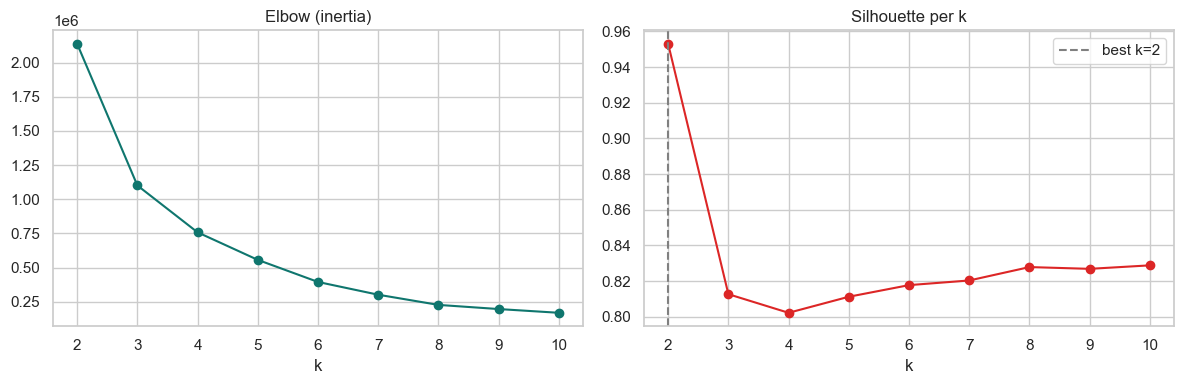

In [3]:
best_k, scores = select_k_kmeans(X, k_range=range(2, 11), random_state=RANDOM_STATE)
ks = scores['k_range']
print(f'Selected k = {best_k} (max silhouette)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, scores['inertia'], 'o-', color='#0F766E'); axes[0].set_title('Elbow (inertia)'); axes[0].set_xlabel('k')
axes[1].plot(ks, scores['silhouette'], 'o-', color='#DC2626'); axes[1].set_title('Silhouette per k'); axes[1].set_xlabel('k')
axes[1].axvline(best_k, ls='--', color='gray', label=f'best k={best_k}'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGDIR / 'kmeans_elbow_silhouette.png', dpi=150)
plt.show()


## 3. Fit all four algorithms

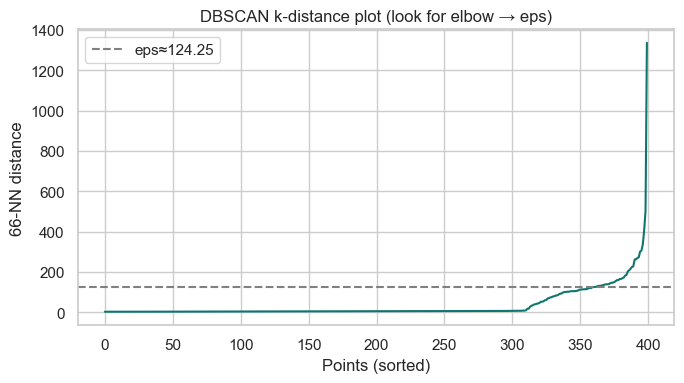

DBSCAN: 1 clusters, 11 noise points


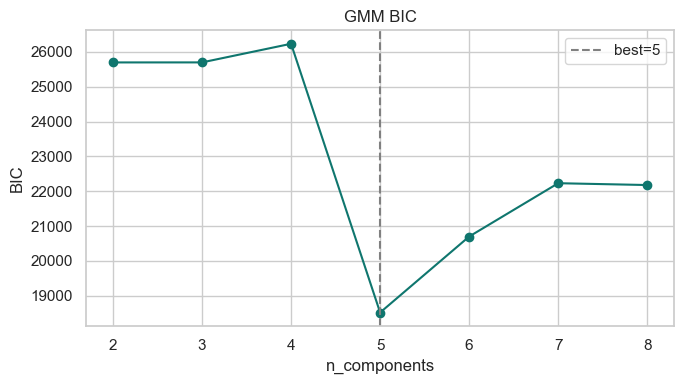

In [4]:
km, km_labels = fit_kmeans(X, k=best_k, random_state=RANDOM_STATE)
agglo_results = {linkage: fit_agglomerative(X, n_clusters=best_k, linkage=linkage)
                 for linkage in ('ward', 'complete', 'average')}

from sklearn.neighbors import NearestNeighbors
ms = 2 * X.shape[1]
nbrs = NearestNeighbors(n_neighbors=ms).fit(X)
dists, _ = nbrs.kneighbors(X)
kdist = np.sort(dists[:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kdist, color='#0F766E'); ax.set_xlabel('Points (sorted)'); ax.set_ylabel(f'{ms}-NN distance')
ax.set_title('DBSCAN k-distance plot (look for elbow → eps)')
eps_estimate = float(np.percentile(kdist, 90))
ax.axhline(eps_estimate, ls='--', color='gray', label=f'eps≈{eps_estimate:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / 'dbscan_kdistance.png', dpi=150)
plt.show()

db_model, db_labels = fit_dbscan(X, eps=eps_estimate, min_samples=ms)
n_db_clusters = len(set(db_labels) - {-1})
n_noise = int((db_labels == -1).sum())
print(f'DBSCAN: {n_db_clusters} clusters, {n_noise} noise points')

from sklearn.mixture import GaussianMixture
bics = []
ks_gmm = list(range(2, 9))
for k in ks_gmm:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=RANDOM_STATE).fit(X)
    bics.append(g.bic(X))
best_k_gmm = ks_gmm[int(np.argmin(bics))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks_gmm, bics, 'o-', color='#0F766E'); ax.axvline(best_k_gmm, ls='--', color='gray', label=f'best={best_k_gmm}')
ax.set_xlabel('n_components'); ax.set_ylabel('BIC'); ax.set_title('GMM BIC'); ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / 'gmm_bic.png', dpi=150)
plt.show()

gmm, gmm_labels, gmm_proba = fit_gmm(X, n_components=best_k_gmm, random_state=RANDOM_STATE)


## 4. Hierarchical dendrograms

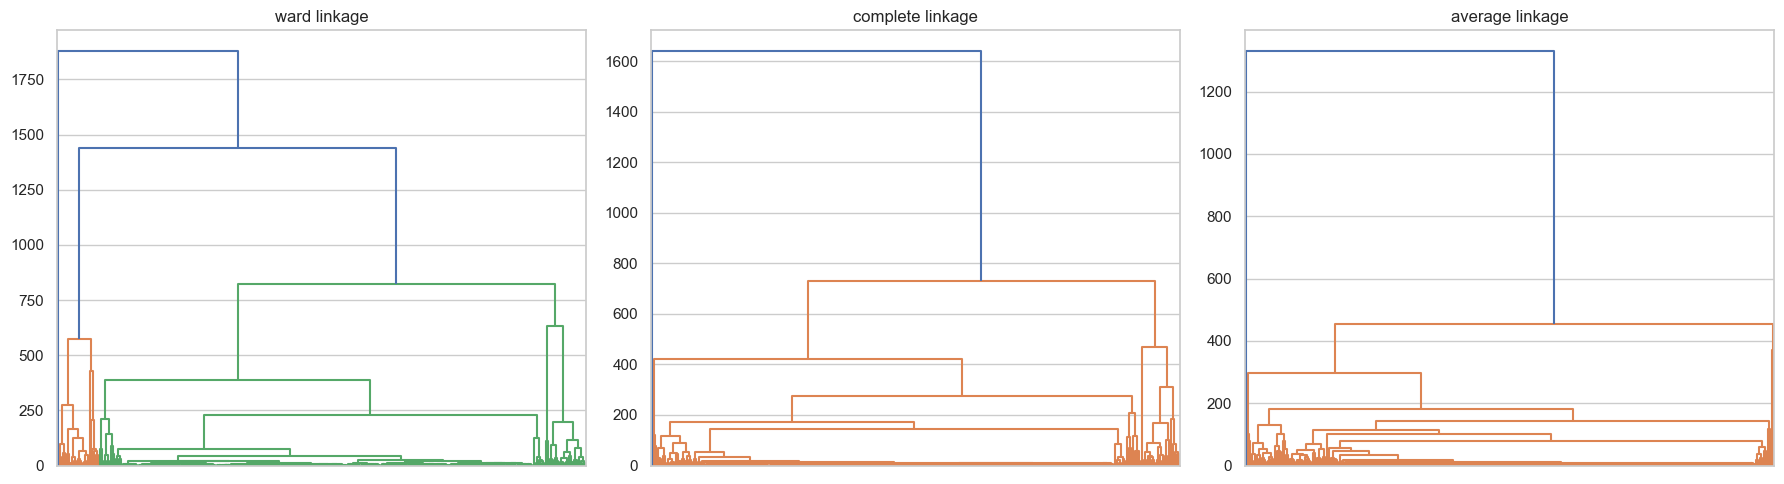

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, linkage_name in zip(axes, ('ward', 'complete', 'average')):
    Z = scipy_linkage(X, method=linkage_name)
    threshold = 0.7 * Z[-best_k+1, 2] if len(Z) >= best_k else 0
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=threshold)
    ax.set_title(f'{linkage_name} linkage')
plt.tight_layout()
plt.savefig(FIGDIR / 'dendrograms.png', dpi=150)
plt.show()


## 5. Evaluation metrics + bootstrap stability

In [6]:
def fit_km(X_): return fit_kmeans(X_, k=best_k, random_state=RANDOM_STATE)[1]
def fit_agglo_ward(X_): return fit_agglomerative(X_, n_clusters=best_k, linkage='ward')[1]
def fit_dbs(X_): return fit_dbscan(X_, eps=eps_estimate, min_samples=ms)[1]
def fit_gmm_(X_): return fit_gmm(X_, n_components=best_k_gmm, random_state=RANDOM_STATE)[1]

results = {}
for name, labels, fit_fn in [
    ('KMeans', km_labels, fit_km),
    ('Agglo-Ward', agglo_results['ward'][1], fit_agglo_ward),
    ('Agglo-Complete', agglo_results['complete'][1], None),
    ('Agglo-Average', agglo_results['average'][1], None),
    ('DBSCAN', db_labels, fit_dbs),
    ('GMM', gmm_labels, fit_gmm_),
]:
    metrics = evaluation_metrics(X, labels)
    if fit_fn is not None:
        stab = bootstrap_stability(X, fit_fn, n_bootstraps=20, sample_frac=0.8, random_state=RANDOM_STATE)
        metrics.update({'mean_ari': stab['mean_ari'], 'std_ari': stab['std_ari']})
    metrics['n_clusters'] = len(set(labels) - {-1})
    results[name] = metrics

comparison = pd.DataFrame(results).T
print(comparison)


                silhouette  davies_bouldin  calinski_harabasz  mean_ari  \
KMeans            0.953063        0.026537         328.290127  0.800000   
Agglo-Ward        0.953063        0.026537         328.290127  0.800000   
Agglo-Complete    0.953063        0.026537         328.290127       NaN   
Agglo-Average     0.953063        0.026537         328.290127       NaN   
DBSCAN                 NaN             NaN                NaN  0.987846   
GMM               0.806837        0.621005         545.353967  0.903647   

                 std_ari  n_clusters  
KMeans          0.400000         2.0  
Agglo-Ward      0.400000         2.0  
Agglo-Complete       NaN         2.0  
Agglo-Average        NaN         2.0  
DBSCAN          0.036672         1.0  
GMM             0.118754         5.0  


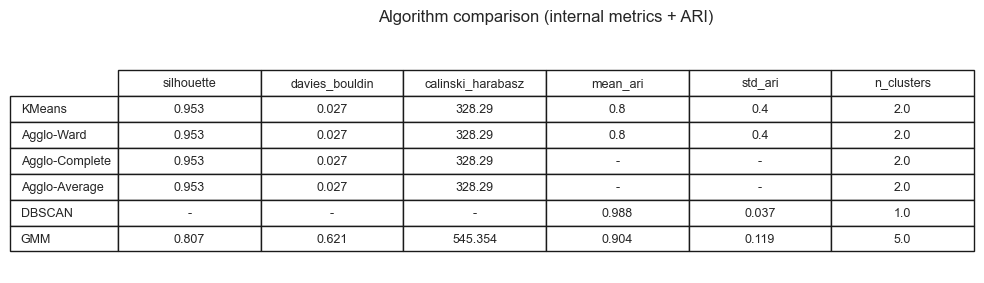

In [7]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
tbl = ax.table(cellText=comparison.round(3).fillna('-').values,
               rowLabels=comparison.index, colLabels=comparison.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0, 1.6)
ax.set_title('Algorithm comparison (internal metrics + ARI)', pad=20)
plt.tight_layout()
plt.savefig(FIGDIR / 'comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

with open('../reports/figures/comparison_table.md', 'w') as f:
    f.write('# Clustering algorithm comparison\n\n')
    f.write(comparison.round(3).to_markdown())


## 6. Final model selection
Persist KMeans (final) + GMM (probabilities for dashboard confidence).


In [8]:
joblib.dump(km, MODELS / 'kmeans.pkl')
joblib.dump(gmm, MODELS / 'gmm.pkl')
print('Saved kmeans.pkl + gmm.pkl')
print('Final model: KMeans, k =', best_k)
print('GMM components:', best_k_gmm)


Saved kmeans.pkl + gmm.pkl
Final model: KMeans, k = 2
GMM components: 5
